<a href="https://colab.research.google.com/github/YakoYakoko/Estudios/blob/main/Clasificaci%C3%B3n_Binaria_y_Evaluaci%C3%B3n_de_Modelos_Profundos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea: Extracción y Descripción de Datasets para Clasificación Binaria

En ciencia de datos, comprender el significado de cada variable (el "Diccionario de Datos") es tan importante como el modelado matemático.

Cuando utilizamos repositorios como `scikit-learn` o `OpenML`, la documentación oficial viene integrada en el mismo objeto que descargamos a través del atributo `.DESCR`.

En este cuaderno descargaremos los dos conjuntos de datos de la tarea e imprimiremos su documentación.

In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer, fetch_openml

## Parte 1: Diagnóstico de Cáncer de Mama (Wisconsin Breast Cancer)
Este es un dataset nativo de `scikit-learn`. Cargamos el objeto y llamamos a su atributo `.DESCR` para leer el significado de las 30 características biométricas.

In [ ]:
# Descarga del dataset
cancer = load_breast_cancer()

# Imprimir la descripción oficial y el diccionario de variables
print("--- DOCUMENTACIÓN DEL DATASET DE CÁNCER DE MAMA ---")
print(cancer.DESCR)

--- DOCUMENTACIÓN DEL DATASET DE CÁNCER DE MAMA ---
.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
  

In [ ]:
# Convertir a un DataFrame de pandas para la exploración de los alumnos
df_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df_cancer['target_class'] = cancer.target # 0: Maligno, 1: Benigno

print("\nVista previa de los datos tabulares:")
display(df_cancer.head())


Vista previa de los datos tabulares:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target_class
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = cancer.target # 0: Maligno, 1: Benigno

print(f"Dimensiones de X: {X.shape}")
display(X.head())

# Partición Train/Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)

# Escalado de Características (Evitando el Data Leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dimensiones de entrenamiento: {X_train_scaled.shape}")
print(f"Dimensiones de prueba: {X_test_scaled.shape}")

Dimensiones de X: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Dimensiones de entrenamiento: (455, 30)
Dimensiones de prueba: (114, 30)


--- REPORTE DEL MODELO ORIGINAL (SIN BALANCEO) ---
              precision    recall  f1-score   support

Se Queda (0)       0.95      0.98      0.97        43
   Se Va (1)       0.99      0.97      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



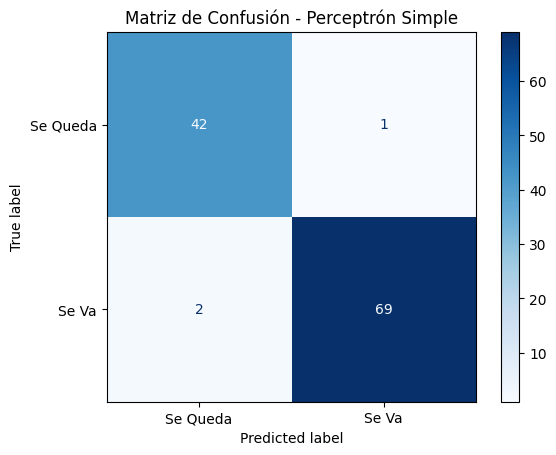

In [4]:
# Entrenar perceptrón estándar
modelo_perceptron = Perceptron(max_iter=1000, eta0=0.1, random_state=42)
modelo_perceptron.fit(X_train_scaled, y_train)
y_pred = modelo_perceptron.predict(X_test_scaled)

print("--- REPORTE DEL MODELO ORIGINAL (SIN BALANCEO) ---")
print(classification_report(y_test, y_pred, target_names=['Se Queda (0)', 'Se Va (1)']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Se Queda', 'Se Va'])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión - Perceptrón Simple")
plt.grid(False)
plt.show()

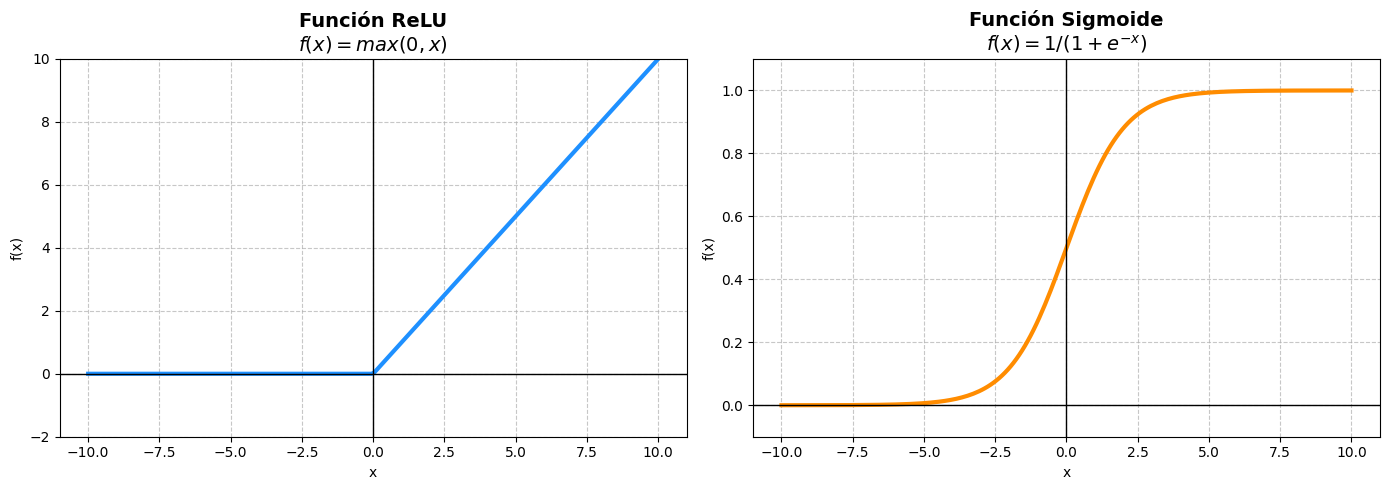

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir el rango de valores para la entrada 'x' (de -10 a 10)
x = np.linspace(-10, 10, 200)

# 2. Definir las operaciones matemáticas de las funciones
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# 3. Configurar la figura con dos paneles (subplots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel Izquierdo: Función ReLU ---
ax1.plot(x, relu(x), color='dodgerblue', linewidth=3)
ax1.set_title("Función ReLU\n$f(x) = max(0, x)$", fontsize=14, fontweight='bold')
ax1.set_xlabel("x")
ax1.set_ylabel("f(x)")
ax1.grid(True, linestyle='--', alpha=0.7)
# Dibujar ejes principales
ax1.axhline(0, color='black', linewidth=1)
ax1.axvline(0, color='black', linewidth=1)
# Limitar el eje y para ver mejor el efecto escalón en el cero
ax1.set_ylim(-2, 10)

# --- Panel Derecho: Función Sigmoide ---
ax2.plot(x, sigmoid(x), color='darkorange', linewidth=3)
ax2.set_title("Función Sigmoide\n$f(x) = 1 / (1 + e^{-x})$", fontsize=14, fontweight='bold')
ax2.set_xlabel("x")
ax2.set_ylabel("f(x)")
ax2.grid(True, linestyle='--', alpha=0.7)
# Dibujar ejes principales
ax2.axhline(0, color='black', linewidth=1)
ax2.axvline(0, color='black', linewidth=1)
# El rango natural de la sigmoide es de 0 a 1
ax2.set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()

Pesos calculados: {0: np.float64(1.3461538461538463), 1: np.float64(0.7954545454545454)}



/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Capa_Oculta_1 (Dense)           │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Oculta_2 (Dense)           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Salida_Probabilidad        │ (None, 1)              │            33 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)


Iniciando entrenamiento...
Entrenamiento completado.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
--- REPORTE FINAL: RED NEURONAL PROFUNDA (MLP) ---
              precision    recall  f1-score   support

     Maligno       0.98      0.95      0.96        43
     Benigno       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



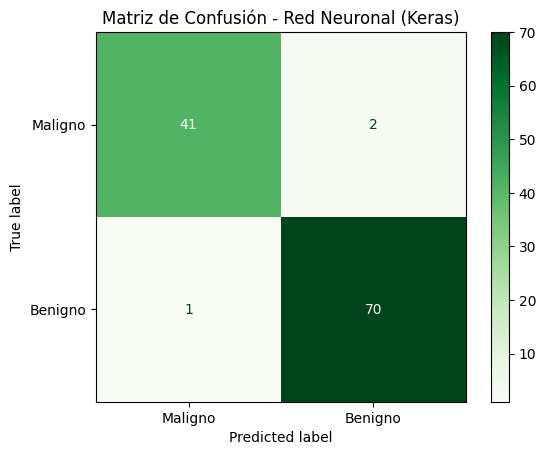

In [8]:
# 1. Calcular diccionarios de pesos para Keras
pesos_clases = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
diccionario_pesos = dict(enumerate(pesos_clases))
print(f"Pesos calculados: {diccionario_pesos}\n")

# 2. Definir Arquitectura de la Red
modelo_nn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],), name="Capa_Oculta_1"),
    Dense(32, activation='relu', name="Capa_Oculta_2"),
    Dense(1, activation='sigmoid', name="Capa_Salida_Probabilidad")
])

# 3. Compilar
modelo_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
modelo_nn.summary()

# 4. Entrenar
print("\nIniciando entrenamiento...")
historia = modelo_nn.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=diccionario_pesos,
    verbose=0
)
print("Entrenamiento completado.\n")

# 5. Predecir y Evaluar
probabilidades_pred = modelo_nn.predict(X_test_scaled)
y_pred_nn = (probabilidades_pred > 0.5).astype("int32")

print("--- REPORTE FINAL: RED NEURONAL PROFUNDA (MLP) ---")
print(classification_report(y_test, y_pred_nn, target_names=['Maligno', 'Benigno']))

cm_nn = confusion_matrix(y_test, y_pred_nn)
disp_nn = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=['Maligno', 'Benigno'])
disp_nn.plot(cmap='Greens')
plt.title("Matriz de Confusión - Red Neuronal (Keras)")
plt.grid(False)
plt.show()

Como podemos observar en base a los diagramas de confusión y los valores r cuadrado. La red neuronal hace un buen trabajo en predecir que tipo de tumor es. De los 114 resultados que utilizamos en esta prueba solo fallo en 3. Podemos observar que tiene buen recall, buena precisión y buen r1score.

## Parte 2: Inteligencia Organizacional (Riesgo Crediticio Alemán)
Este dataset lo traemos de OpenML, una plataforma de datos abiertos. La función `fetch_openml` también incluye la metadata del creador original.

In [16]:
from sklearn.datasets import fetch_openml

# Descarga del dataset desde OpenML
credito = fetch_openml(name='credit-g', version=1, as_frame=True, parser='auto')

# Imprimir la descripción de las variables (estado de cuenta, historial, propósito, etc.)
print("--- DOCUMENTACIÓN DEL DATASET DE RIESGO CREDITICIO ---")
print(credito.DESCR)

--- DOCUMENTACIÓN DEL DATASET DE RIESGO CREDITICIO ---
**Author**: Dr. Hans Hofmann  
**Source**: [UCI](https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data)) - 1994    
**Please cite**: [UCI](https://archive.ics.uci.edu/ml/citation_policy.html)

**German Credit dataset**  
This dataset classifies people described by a set of attributes as good or bad credit risks.

This dataset comes with a cost matrix: 
``` 
Good  Bad (predicted)  
Good   0    1   (actual)  
Bad    5    0  
```

It is worse to class a customer as good when they are bad (5), than it is to class a customer as bad when they are good (1).  

### Attribute description  

1. Status of existing checking account, in Deutsche Mark.  
2. Duration in months  
3. Credit history (credits taken, paid back duly, delays, critical accounts)  
4. Purpose of the credit (car, television,...)  
5. Credit amount  
6. Status of savings account/bonds, in Deutsche Mark.  
7. Present employment, in number of years.  
8. Install

In [17]:
# Como usamos as_frame=True, podemos extraer el DataFrame completo directamente
df_credito = credito.frame

print("\nVista previa de los datos tabulares (Nota las variables categóricas en texto):")
display(df_credito.head())


Vista previa de los datos tabulares (Nota las variables categóricas en texto):


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


Procesamiento y transformación de valores categóricos con onehotencoding.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# 1. Separar la variable objetivo (y) y las predictoras (X)
y_raw = df_credito['class']
X_raw = df_credito.drop(columns=['class'])

# 2. Mapear: Buen Riesgo = 0, Mal Riesgo = 1
y = y_raw.map({'good': 0, 'bad': 1}).astype(int).values

print("Distribución de clases:")
print(pd.Series(y).value_counts().rename(index={0: 'Buen Riesgo (0)', 1: 'Mal Riesgo (1)'}))

# 3. Codificar variables categóricas con One-Hot Encoding
# dtype=float evita booleanos y facilita el trabajo numérico
X_encoded = pd.get_dummies(X_raw, drop_first=True, dtype=float)
print(f"\nDimensiones de X tras One-Hot Encoding: {X_encoded.shape}")

# 4. Partición Train / Test (80% / 20%) estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42, stratify=y
)

# 5. Escalado estándar (fit solo en train para evitar data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")

Distribución de clases:
Buen Riesgo (0)    700
Mal Riesgo (1)     300
Name: count, dtype: int64

Dimensiones de X tras One-Hot Encoding: (1000, 48)
X_train_scaled: (800, 48)
X_test_scaled: (200, 48)


Red neuronal

In [19]:
# 1. Calcular pesos balanceados de las clases
pesos = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(pesos))
print(f"Pesos de penalización calculados: {class_weights_dict}")

# 2. Definir la arquitectura de la red neuronal profunda
tf.keras.utils.set_random_seed(42)

modelo_credito = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu', name="Capa_Oculta_1"),
    Dense(32, activation='relu', name="Capa_Oculta_2"),
    Dense(1, activation='sigmoid', name="Capa_Salida")
])

# 3. Compilación del modelo
modelo_credito.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

modelo_credito.summary()

# 4. Entrenamiento con class_weight integrado
print("\nEntrenando la red neuronal...")
historial = modelo_credito.fit(
    X_train_scaled,
    y_train,
    epochs=60,
    batch_size=32,
    validation_split=0.15,
    class_weight=class_weights_dict,
    verbose=0
)
print("Entrenamiento finalizado.")

Pesos de penalización calculados: {0: np.float64(0.7142857142857143), 1: np.float64(1.6666666666666667)}


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Capa_Oculta_1 (Dense)           │ (None, 64)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Oculta_2 (Dense)           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Salida (Dense)             │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando la red neuronal...
Entrenamiento finalizado.


Matriz de confusión

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
--- REPORTE DE CLASIFICACIÓN (RIESGO CREDITICIO) ---
                 precision    recall  f1-score   support

Buen Riesgo (0)       0.81      0.83      0.82       140
 Mal Riesgo (1)       0.57      0.53      0.55        60

       accuracy                           0.74       200
      macro avg       0.69      0.68      0.68       200
   weighted avg       0.74      0.74      0.74       200



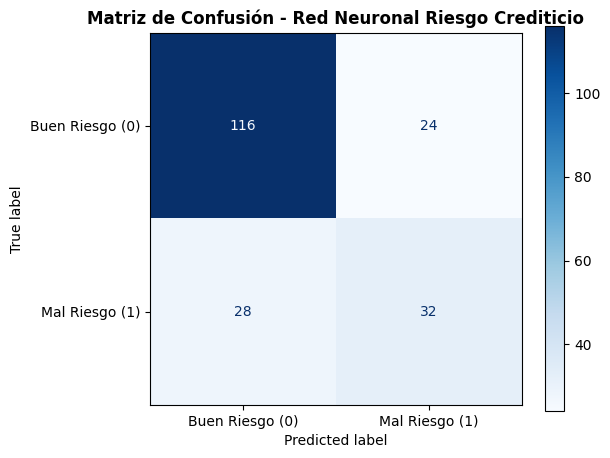

In [20]:
# 1. Predicciones en el conjunto de prueba
y_probs = modelo_credito.predict(X_test_scaled)
y_pred = (y_probs >= 0.5).astype(int).flatten()

# 2. Reporte de Clasificación
print("--- REPORTE DE CLASIFICACIÓN (RIESGO CREDITICIO) ---")
print(classification_report(y_test, y_pred, target_names=['Buen Riesgo (0)', 'Mal Riesgo (1)']))

# 3. Matriz de Confusión etiquetada
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Buen Riesgo (0)', 'Mal Riesgo (1)'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Matriz de Confusión - Red Neuronal Riesgo Crediticio", fontsize=12, fontweight='bold')
plt.grid(False)
plt.show()

Analisis:
Este modelo intenta predecir si un cliente es cumplidor o no a la hora de querer sacar un crédito, los clientes cumplidores son 0 y los no cumplidores son 1.

Como podemos observar nuestro modelo aun no esta listo, ya que las metricas para predecir clientes cumplidores son buenas (precisión de .8, recall de .83, f1 score de .82). Sin embargo podemos notar que las metricas para clientes que representan  un riesgo para el banco a la hora de conceder prestamos aun no estan listas (precisión .57, recall .53, f1-score.55).

Aunque podemos observar que tiene un accuracy de .74 el modelo aun tiene dificultades para identificar clientes morosos, talvez con un analisis que tenga una mejor limpieza de datos podamos mejorar esos números